
# Presentation companion — spatio-temporal kriging

High-resolution slide-ready figures for the class presentation. Every figure is
saved as a PNG under `presentation_figures/` at 200 DPI with enlarged fonts.
Talking points for each slide are in `presentation_figures/slide_notes.md`.


In [1]:

from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import cm
from matplotlib.colors import Normalize, TwoSlopeNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.spatial.distance import cdist
from scipy.optimize import least_squares

import kriging_lib as K

SEED = 20260421
rng = np.random.default_rng(SEED)

HERE = Path.cwd()
PFIG = HERE / "presentation_figures"
PFIG.mkdir(exist_ok=True)
DATADIR = HERE / "kriging_data"

plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 200,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 13, "axes.labelsize": 14, "axes.titlesize": 15,
    "axes.titleweight": "bold", "legend.fontsize": 10,
    "xtick.labelsize": 11, "ytick.labelsize": 11, "lines.linewidth": 2.0,
})

def savefig(fig, name):
    out = PFIG / f"{name}.png"
    fig.savefig(out, bbox_inches="tight", facecolor="white")
    print(f"  saved {out.name}")

def load_period(tag):
    meta = pd.read_csv(DATADIR / f"stations_meta_{tag}.csv")
    obs = pd.read_csv(DATADIR / f"stations_obs_{tag}.csv", parse_dates=["time"])
    full_idx = pd.date_range(obs["time"].min(), obs["time"].max(), freq="h")
    wide = obs.pivot_table(index="time", columns="station_id", values="temp").reindex(full_idx)
    return meta.set_index("station_id"), wide

meta_sum, wide_sum = load_period("summer_2020")
TARGET_LAT, TARGET_LON = 33.1, -116.6
meta_sum["dist_km"] = K.haversine_km(
    TARGET_LAT, TARGET_LON, meta_sum["latitude"].values, meta_sum["longitude"].values,
)
print(f"Summer 2020: {wide_sum.shape[1]} stations x {wide_sum.shape[0]} hours")


Summer 2020: 29 stations x 168 hours



# SLIDE 1 — Data overview (3 figures)


  saved slide1_station_map.png


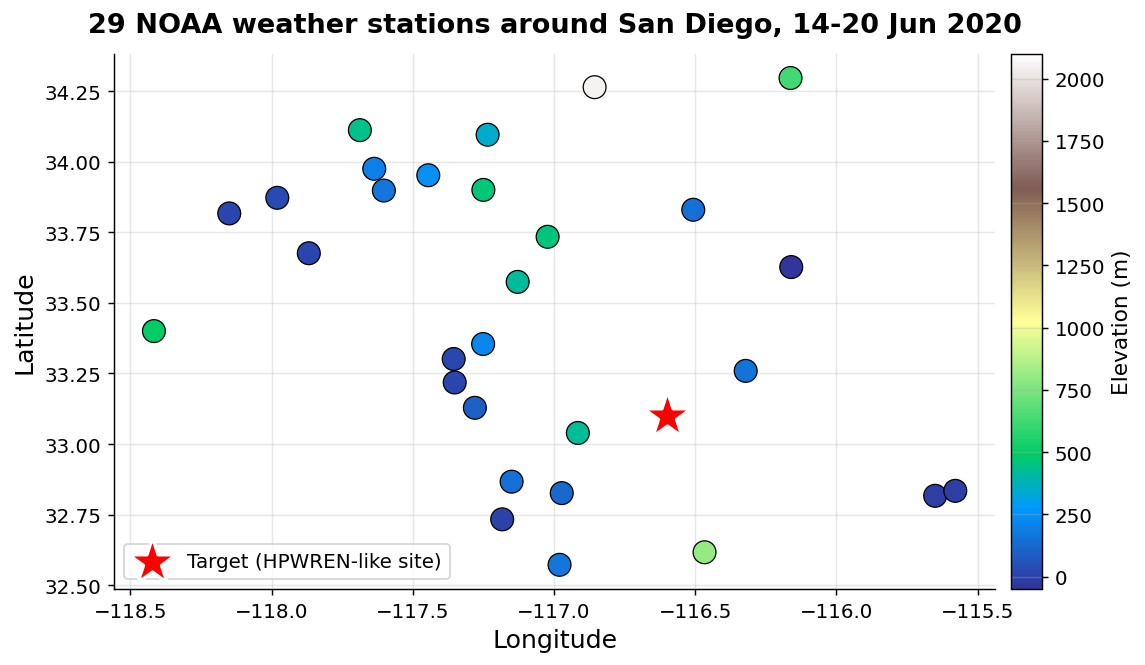

In [2]:

fig, ax = plt.subplots(figsize=(9, 6.2))
sc = ax.scatter(meta_sum["longitude"], meta_sum["latitude"],
                c=meta_sum["elevation"], cmap="terrain",
                s=160, edgecolor="black", linewidth=0.7, vmin=-50, vmax=2100, zorder=3)
ax.scatter([TARGET_LON], [TARGET_LAT], marker="*", color="red", s=750,
           edgecolor="white", linewidth=1.8, zorder=5, label="Target (HPWREN-like site)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("29 NOAA weather stations around San Diego, 14-20 Jun 2020", pad=12)
ax.legend(loc="lower left", fontsize=11)
div = make_axes_locatable(ax); cax = div.append_axes("right", size="3.5%", pad=0.12)
cb = fig.colorbar(sc, cax=cax); cb.set_label("Elevation (m)", fontsize=12)
ax.set_aspect("equal")
fig.tight_layout()
savefig(fig, "slide1_station_map")
plt.show()


  saved slide1_time_series.png


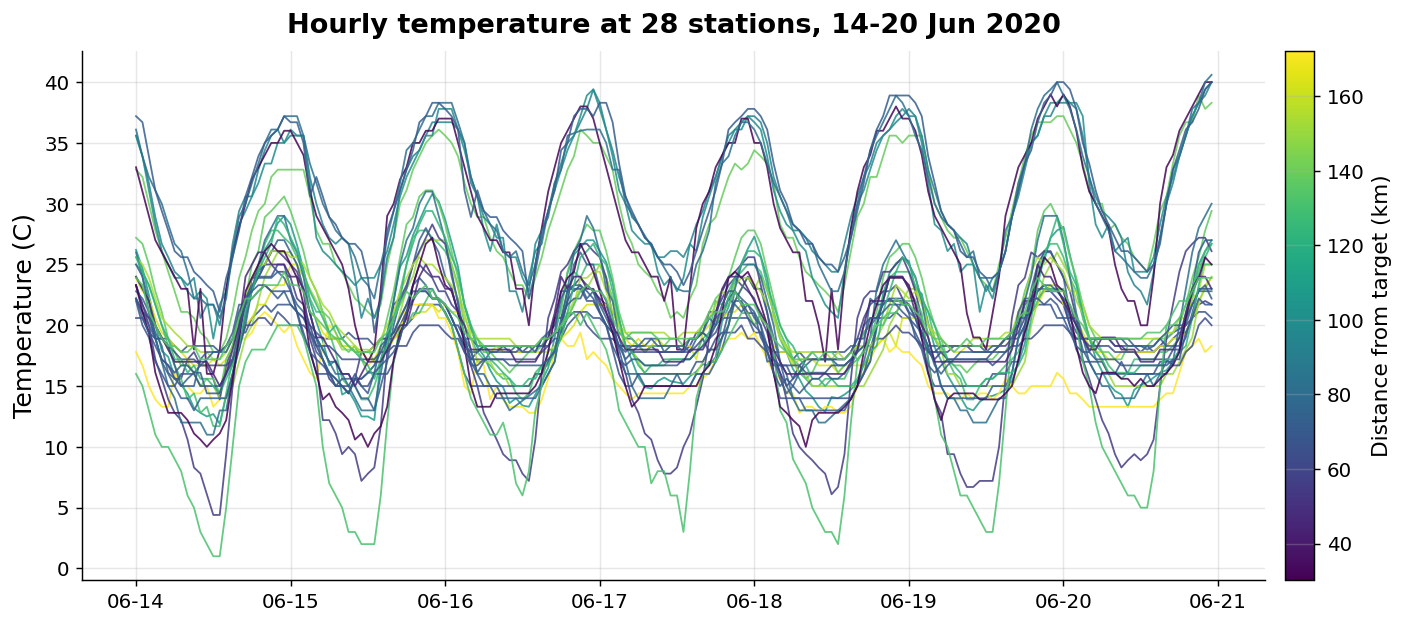

In [3]:

complete = wide_sum.dropna(axis=1, thresh=150)
n = complete.shape[1]
norm = Normalize(meta_sum.loc[complete.columns, "dist_km"].min(),
                 meta_sum.loc[complete.columns, "dist_km"].max())
cmap = cm.viridis

fig, ax = plt.subplots(figsize=(11, 5))
for sid in complete.columns:
    color = cmap(norm(meta_sum.loc[sid, "dist_km"]))
    series = complete[sid].dropna()
    ax.plot(series.index, series.values, color=color, lw=1.0, alpha=0.85)
ax.set_ylabel("Temperature (C)")
ax.set_title(f"Hourly temperature at {n} stations, 14-20 Jun 2020", pad=10)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
sm = cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
div = make_axes_locatable(ax); cax = div.append_axes("right", size="2.5%", pad=0.15)
cb = fig.colorbar(sm, cax=cax); cb.set_label("Distance from target (km)", fontsize=12)
fig.tight_layout()
savefig(fig, "slide1_time_series")
plt.show()


  saved slide1_distance_elevation.png


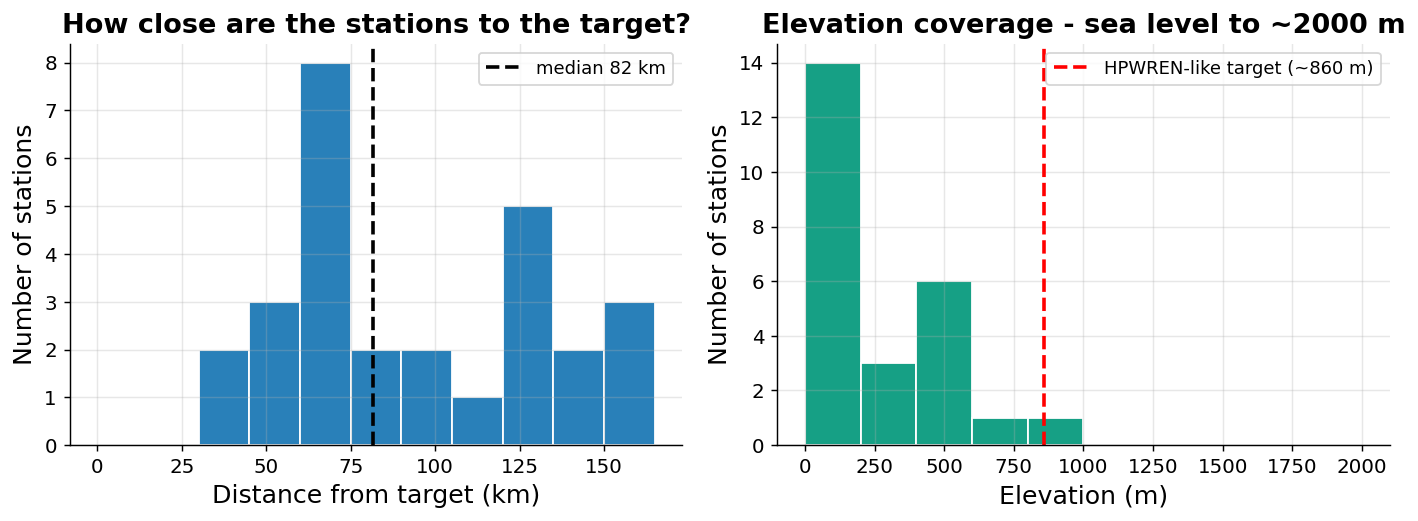

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ax = axes[0]
ax.hist(meta_sum["dist_km"], bins=np.arange(0, 180, 15),
        color="#2980b9", edgecolor="white")
ax.axvline(meta_sum["dist_km"].median(), ls="--", color="black", lw=2,
           label=f"median {meta_sum['dist_km'].median():.0f} km")
ax.set_xlabel("Distance from target (km)"); ax.set_ylabel("Number of stations")
ax.set_title("How close are the stations to the target?"); ax.legend()

ax = axes[1]
elev = meta_sum["elevation"].dropna()
ax.hist(elev, bins=np.arange(0, 2200, 200), color="#16a085", edgecolor="white")
ax.axvline(860, ls="--", color="red", lw=2, label="HPWREN-like target (~860 m)")
ax.set_xlabel("Elevation (m)"); ax.set_ylabel("Number of stations")
ax.set_title("Elevation coverage - sea level to ~2000 m"); ax.legend()

fig.tight_layout()
savefig(fig, "slide1_distance_elevation")
plt.show()



# SLIDE 2 - Variogram (2 figures)


  saved slide2_variogram_1d.png


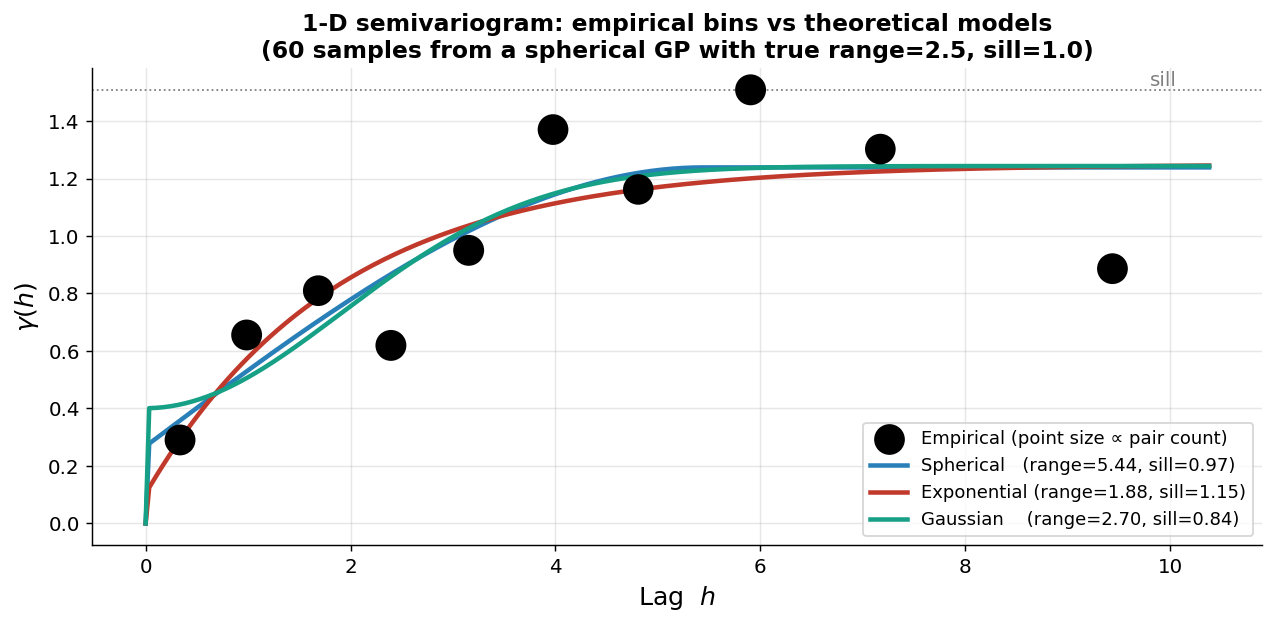

In [5]:

import gstools as gs
true_sill = 1.0; true_range = 2.5
model_true = gs.Spherical(dim=1, var=true_sill, len_scale=true_range, nugget=0.05)
srf = gs.SRF(model_true, seed=SEED)
x_dense = np.linspace(0, 12, 200)
z_dense = srf((x_dense,))

rng_demo = np.random.default_rng(SEED)
idx = np.sort(rng_demo.choice(len(x_dense), 60, replace=False))
x_obs = x_dense[idx]; y_obs = z_dense[idx] + rng_demo.normal(0, 0.1, idx.size)

ii, jj = np.triu_indices(len(x_obs), k=1)
h_pairs = np.abs(x_obs[ii] - x_obs[jj]); d_pairs = (y_obs[ii] - y_obs[jj]) ** 2
h_c, g_c, n_c = K.empirical_variogram_1d(h_pairs, d_pairs, n_bins=10)

def fit_model(model_fn):
    def resid(theta):
        s, r, ng = theta
        return model_fn(h_c, s, r, ng) - g_c
    th0 = [float(np.nanmax(g_c)), float(np.nanmedian(h_c)), 0.05]
    return least_squares(resid, th0, bounds=([1e-6, 1e-6, 0.0], [np.inf]*3)).x

th_sph = fit_model(K.spherical); th_exp = fit_model(K.exponential); th_gau = fit_model(K.gaussian)
h_fine = np.linspace(0, h_c.max() * 1.1, 300)

fig, ax = plt.subplots(figsize=(10, 5))
sizes = 40 + 220 * n_c / n_c.max()
ax.scatter(h_c, g_c, s=sizes, color="black", zorder=5,
           label="Empirical (point size ∝ pair count)")
ax.plot(h_fine, K.spherical(h_fine, *th_sph), color="#2980b9", lw=2.5,
        label=f"Spherical   (range={th_sph[1]:.2f}, sill={th_sph[0]:.2f})")
ax.plot(h_fine, K.exponential(h_fine, *th_exp), color="#c0392b", lw=2.5,
        label=f"Exponential (range={th_exp[1]:.2f}, sill={th_exp[0]:.2f})")
ax.plot(h_fine, K.gaussian(h_fine, *th_gau), color="#16a085", lw=2.5,
        label=f"Gaussian    (range={th_gau[1]:.2f}, sill={th_gau[0]:.2f})")
ax.axhline(float(np.nanmax(g_c)), ls=":", color="gray", lw=1)
ax.text(h_fine[-1] * 0.97, float(np.nanmax(g_c)), "sill", va="bottom", ha="right",
        color="gray", fontsize=11)
ax.set_xlabel("Lag  $h$"); ax.set_ylabel(r"$\gamma(h)$")
ax.set_title(f"1-D semivariogram: empirical bins vs theoretical models\n"
             f"(60 samples from a spherical GP with true range={true_range}, sill={true_sill})",
             fontsize=13)
ax.legend(loc="lower right", fontsize=10)
fig.tight_layout()
savefig(fig, "slide2_variogram_1d")
plt.show()


  saved slide2_st_variogram.png


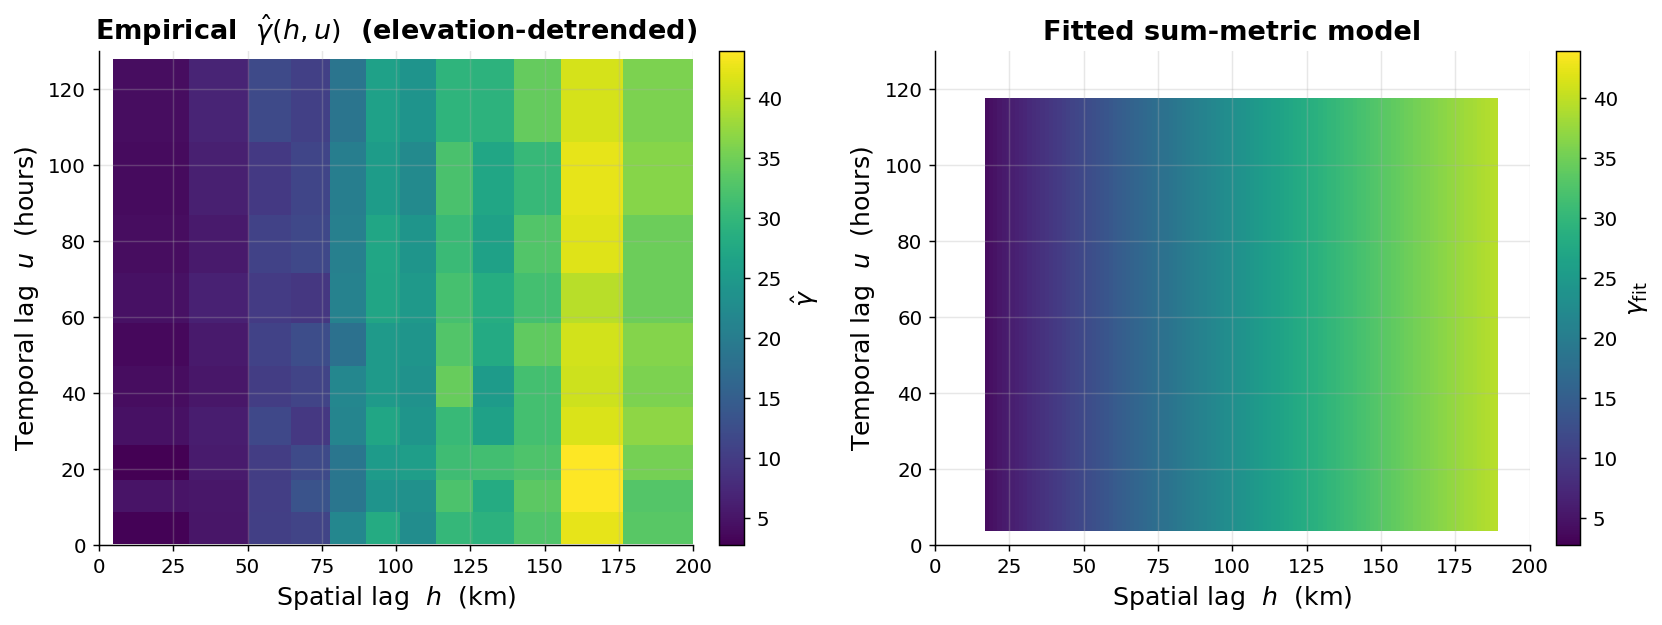

Sum-metric parameters (on elevation-detrended residuals):
  nugget=0.00  s_sill=48.85  s_range=305.8 km
  t_sill=0.00  t_range=11324.2 h  j_sill=0.04
  j_range=401.6  k(anisotropy)=0.00 km/h


In [6]:

def panel_from_wide(meta, wide):
    stations = [s for s in wide.columns if s in meta.index]
    wide = wide[stations]
    xy = np.column_stack([meta.loc[stations, "latitude"].values,
                          meta.loc[stations, "longitude"].values])
    dist = np.zeros((len(stations), len(stations)))
    for i in range(len(stations)):
        dist[i] = K.haversine_km(xy[i, 0], xy[i, 1], xy[:, 0], xy[:, 1])
    return stations, wide.values.T, dist, xy

stations_s, Y_s, dist_s, xy_s = panel_from_wide(meta_sum, wide_sum)
t_hours = np.arange(Y_s.shape[1], dtype=float)

mean_per_hour = np.nanmean(Y_s, axis=0)
Y_anom = Y_s - mean_per_hour[None, :]
elev = meta_sum.loc[stations_s, "elevation"].values
elev[~np.isfinite(elev)] = np.nanmedian(elev[np.isfinite(elev)])
station_mean = np.nanmean(Y_anom, axis=1)
Xd = np.column_stack([np.ones_like(elev), elev])
beta, *_ = np.linalg.lstsq(Xd, station_mean, rcond=None)
Y_resid = Y_anom - (Xd @ beta)[:, None]

H, U, Gamma, Nc = K.empirical_st_variogram(
    Y_resid, dist_s, t_axis=t_hours, max_pairs=80000, rng=np.random.default_rng(SEED),
)
p_rk, _ = K.fit_sum_metric(H, U, Gamma, Nc)

H_fine = np.linspace(np.nanmin(H), np.nanmax(H), 120)
U_fine = np.linspace(np.nanmin(U), np.nanmax(U), 80)
Hf, Uf = np.meshgrid(H_fine, U_fine, indexing="ij")
Gfit = K.gamma_sum_metric(Hf, Uf, p_rk)
vmin = float(np.nanmin(Gamma)); vmax = float(np.nanmax(Gamma))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
im0 = axes[0].pcolormesh(H, U, Gamma, cmap="viridis", shading="auto",
                         vmin=vmin, vmax=vmax)
axes[0].set_xlim(0, 200); axes[0].set_ylim(0, 130)
axes[0].set_xlabel("Spatial lag  $h$  (km)"); axes[0].set_ylabel("Temporal lag  $u$  (hours)")
axes[0].set_title(r"Empirical  $\hat\gamma(h,u)$  (elevation-detrended)")
fig.colorbar(im0, ax=axes[0], fraction=0.045, pad=0.04).set_label(r"$\hat\gamma$")

im1 = axes[1].pcolormesh(Hf, Uf, Gfit, cmap="viridis", shading="auto",
                         vmin=vmin, vmax=vmax)
axes[1].set_xlim(0, 200); axes[1].set_ylim(0, 130)
axes[1].set_xlabel("Spatial lag  $h$  (km)"); axes[1].set_ylabel("Temporal lag  $u$  (hours)")
axes[1].set_title("Fitted sum-metric model")
fig.colorbar(im1, ax=axes[1], fraction=0.045, pad=0.04).set_label(r"$\gamma_{\mathrm{fit}}$")
fig.tight_layout()
savefig(fig, "slide2_st_variogram")
plt.show()

print(f"Sum-metric parameters (on elevation-detrended residuals):")
print(f"  nugget={p_rk.nugget:.2f}  s_sill={p_rk.s_sill:.2f}  s_range={p_rk.s_range:.1f} km")
print(f"  t_sill={p_rk.t_sill:.2f}  t_range={p_rk.t_range:.1f} h  j_sill={p_rk.j_sill:.2f}")
print(f"  j_range={p_rk.j_range:.1f}  k(anisotropy)={p_rk.k:.2f} km/h")



# SLIDES 3 + 4 - Building the prediction (3 figures)

Instead of predicting at a hypothetical site, we **leave one real station out**
(San Diego International Airport, 72290, coastal sea-level) and predict its
168 hourly temperatures from the other 28 stations. We therefore have true
ground-truth observations to compare the prediction against.


In [7]:

R_earth = 6371.0088
lat_rad = np.deg2rad(meta_sum.loc[stations_s, "latitude"].values)
lon_rad = np.deg2rad(meta_sum.loc[stations_s, "longitude"].values)
mean_lat_rad = lat_rad.mean()
X_km = np.column_stack([
    R_earth * (lon_rad - lon_rad.mean()) * np.cos(mean_lat_rad),
    R_earth * (lat_rad - lat_rad.mean()),
])

TARGET_SID = "KRNM0"
i_target = stations_s.index(TARGET_SID)
keep = np.arange(len(stations_s)) != i_target
elev_k = elev[keep]
mean_per_hour_k = np.nanmean(Y_s[keep], axis=0)
Y_anom_k = Y_s[keep] - mean_per_hour_k[None, :]
station_mean_k = np.nanmean(Y_anom_k, axis=1)
Xd_k = np.column_stack([np.ones_like(elev_k), elev_k])
beta_k, *_ = np.linalg.lstsq(Xd_k, station_mean_k, rcond=None)
Y_resid_k = Y_anom_k - (Xd_k @ beta_k)[:, None]

dist_k = dist_s[np.ix_(keep, keep)]
H_k, U_k, G_k, Nc_k = K.empirical_st_variogram(
    Y_resid_k, dist_k, t_axis=t_hours, max_pairs=40000, rng=np.random.default_rng(SEED),
)
p_k, _ = K.fit_sum_metric(H_k, U_k, G_k, Nc_k)
X_km_k = X_km[keep]

target_xy_km = X_km[i_target]
target_obs = Y_s[i_target]
target_name = meta_sum.loc[TARGET_SID, "name"]
target_elev = elev[i_target]
print(f"Target: {TARGET_SID}  '{target_name}'  elev={target_elev:.0f} m")


Target: KRNM0  'Ramona / Rosemont'  elev=425 m


  saved slide3_kriging_weights.png


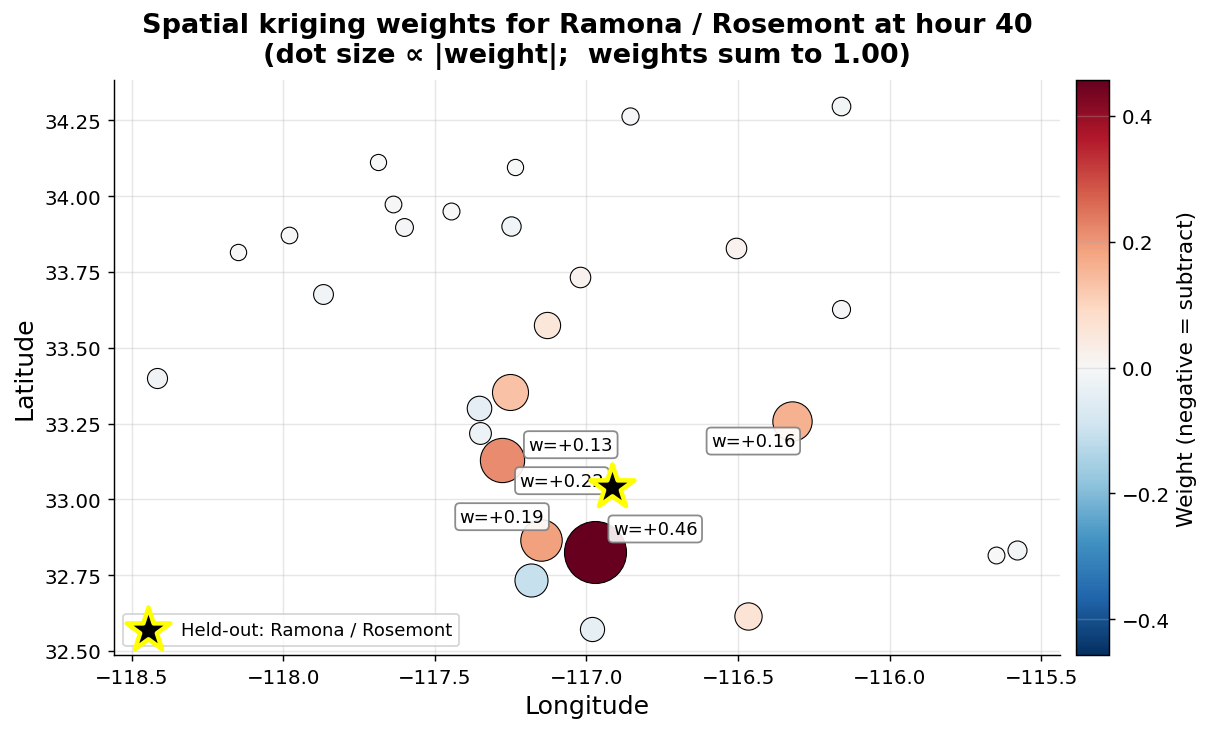

In [8]:

t_demo = 40
y_at_hour = Y_resid_k[:, t_demo]
mask_hour = ~np.isnan(y_at_hour)
X_hour = X_km_k[mask_hour]
y_hour = y_at_hour[mask_hour]
stations_hour = np.where(keep)[0][mask_hour]

def gamma_purespace(h):
    return K.gamma_sum_metric(np.asarray(h), np.zeros_like(np.asarray(h, dtype=float)), p_k)

n_h = len(y_hour)
D_hour = cdist(X_hour, X_hour)
G_hour = gamma_purespace(D_hour)
A_h = np.zeros((n_h + 1, n_h + 1))
A_h[:n_h, :n_h] = G_hour + 1e-10 * np.eye(n_h)
A_h[:n_h, n_h] = 1.0; A_h[n_h, :n_h] = 1.0
d_to_target = cdist(np.array([target_xy_km]), X_hour)[0]
g0_hour = gamma_purespace(d_to_target)
b_h = np.ones(n_h + 1); b_h[:n_h] = g0_hour
w_hour = np.linalg.lstsq(A_h, b_h, rcond=None)[0][:n_h]

w_by_station = np.zeros(len(stations_s))
w_by_station[stations_hour] = w_hour

non_target = np.arange(len(stations_s)) != i_target
vals = w_by_station[non_target]
vmax_abs = max(abs(vals.min()), abs(vals.max()), 0.02)

fig, ax = plt.subplots(figsize=(9.5, 6.5))
norm = TwoSlopeNorm(vmin=-vmax_abs, vcenter=0, vmax=vmax_abs)
cmap = plt.cm.RdBu_r
for i, sid in enumerate(stations_s):
    if i == i_target: continue
    size = 80 + 1100 * abs(w_by_station[i]) / max(1e-9, np.abs(vals).max())
    c = cmap(norm(w_by_station[i]))
    ax.scatter(meta_sum.loc[sid, "longitude"], meta_sum.loc[sid, "latitude"],
               s=size, color=c, edgecolor="black", linewidth=0.6, zorder=3)
ax.scatter([meta_sum.loc[TARGET_SID, "longitude"]], [meta_sum.loc[TARGET_SID, "latitude"]],
           marker="*", color="black", s=650, edgecolor="yellow", linewidth=2.5,
           zorder=6, label=f"Held-out: {target_name}")

order = np.argsort(-np.abs(w_by_station))[:5]
label_offsets = [(10, 10), (10, -14), (-45, 10), (-45, -14), (10, -32)]
for oi, k in enumerate(order):
    if k == i_target: continue
    sid = stations_s[k]
    dx, dy = label_offsets[oi % len(label_offsets)]
    ax.annotate(f"w={w_by_station[k]:+.2f}",
                (meta_sum.loc[sid, "longitude"], meta_sum.loc[sid, "latitude"]),
                fontsize=10, xytext=(dx, dy), textcoords="offset points",
                bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="gray",
                          alpha=0.9))
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"Spatial kriging weights for {target_name} at hour {t_demo}\n"
             f"(dot size ∝ |weight|;  weights sum to {w_by_station.sum():.2f})", pad=10)
sm = cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
div = make_axes_locatable(ax); cax = div.append_axes("right", size="3.5%", pad=0.12)
cb = fig.colorbar(sm, cax=cax); cb.set_label("Weight (negative = subtract)", fontsize=12)
ax.legend(loc="lower left")
ax.set_aspect("equal")
fig.tight_layout()
savefig(fig, "slide3_kriging_weights")
plt.show()


  saved slide4_prediction_trajectory.png


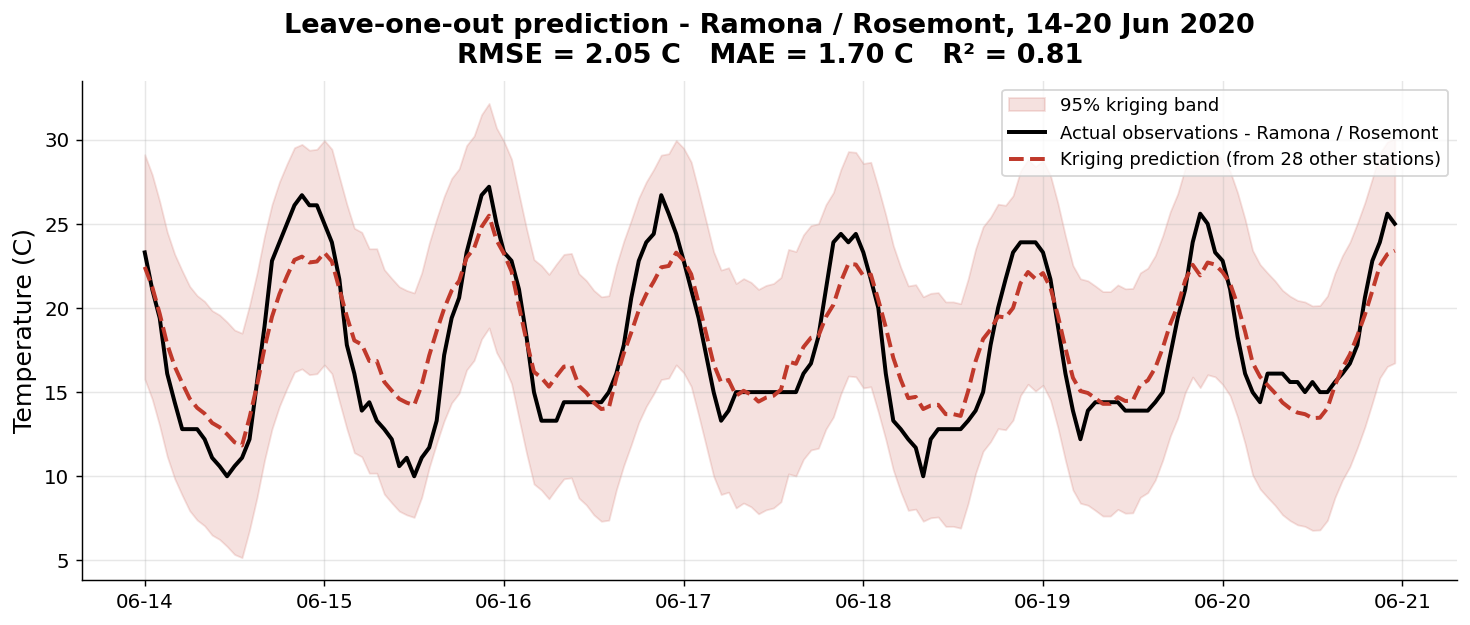

In [9]:

obs_rows = []; obs_t = []; obs_y = []
for j in range(Y_s.shape[1]):
    v = Y_resid_k[:, j]; m = ~np.isnan(v)
    if m.any():
        obs_rows.append(X_km_k[m]); obs_t.append(np.full(m.sum(), t_hours[j]))
        obs_y.append(v[m])
X_obs_r = np.vstack(obs_rows); t_obs_r = np.concatenate(obs_t); y_obs_r = np.concatenate(obs_y)

X_pred = np.tile(target_xy_km[None, :], (Y_s.shape[1], 1))
preds_resid, kvar = K.ordinary_st_kriging_local(
    X_obs_r, t_obs_r, y_obs_r, X_pred, t_hours, p_k,
    n_neighbors=min(40, len(y_obs_r)),
)
preds_target = mean_per_hour_k + beta_k[0] + beta_k[1] * target_elev + preds_resid
ksd = np.sqrt(np.clip(kvar, 0, None))

mask = np.isfinite(target_obs)
rmse_t = K.rmse(target_obs[mask], preds_target[mask])
mae_t = K.mae(target_obs[mask], preds_target[mask])
r2_t = K.r2_score(target_obs[mask], preds_target[mask])

times = wide_sum.index

fig, ax = plt.subplots(figsize=(11.5, 5))
ax.fill_between(times, preds_target - 1.96 * ksd, preds_target + 1.96 * ksd,
                color="#c0392b", alpha=0.15, label="95% kriging band")
ax.plot(times, target_obs, color="black", lw=2.2,
        label=f"Actual observations - {target_name}")
ax.plot(times, preds_target, color="#c0392b", lw=2.2, ls="--",
        label=f"Kriging prediction (from 28 other stations)")
ax.set_ylabel("Temperature (C)")
ax.set_title(f"Leave-one-out prediction - {target_name}, 14-20 Jun 2020\n"
             f"RMSE = {rmse_t:.2f} C   MAE = {mae_t:.2f} C   R² = {r2_t:.2f}", pad=10)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax.legend(loc="upper right")
fig.tight_layout()
savefig(fig, "slide4_prediction_trajectory")
plt.show()


  saved slide4_prediction_zoom.png


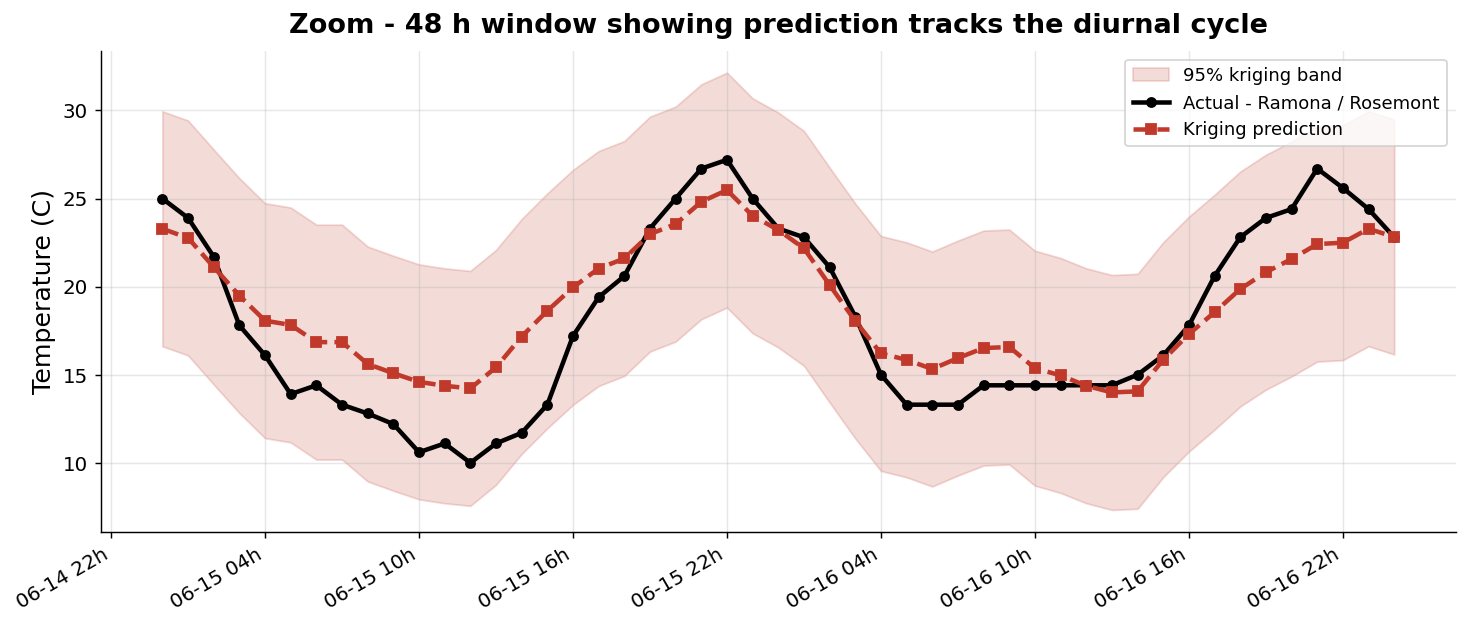

In [10]:

zoom_mask = (times >= pd.Timestamp("2020-06-15")) & (times <= pd.Timestamp("2020-06-17"))
fig, ax = plt.subplots(figsize=(11.5, 5))
ax.fill_between(times[zoom_mask],
                preds_target[zoom_mask] - 1.96 * ksd[zoom_mask],
                preds_target[zoom_mask] + 1.96 * ksd[zoom_mask],
                color="#c0392b", alpha=0.18, label="95% kriging band")
ax.plot(times[zoom_mask], target_obs[zoom_mask], color="black", lw=2.5, marker="o", ms=5,
        label=f"Actual - {target_name}")
ax.plot(times[zoom_mask], preds_target[zoom_mask], color="#c0392b", lw=2.5, ls="--",
        marker="s", ms=5, label="Kriging prediction")
ax.set_ylabel("Temperature (C)")
ax.set_title("Zoom - 48 h window showing prediction tracks the diurnal cycle", pad=10)
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %Hh"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.legend(loc="upper right")
fig.tight_layout()
savefig(fig, "slide4_prediction_zoom")
plt.show()



# SLIDE 5 - Measuring accuracy (3 figures)


In [11]:

results = pd.read_csv("kriging_figures/final_results.csv")
print(results.to_string(index=False))


                                  analysis     rmse      mae        r2           period
 Synthetic — weather stations (n=24, wide) 0.949322 0.869716  0.955591 7 synthetic days
Synthetic — local sensors (n=44, 1 km box) 0.154598 0.125127  0.998822 7 synthetic days
  Real NOAA — ordinary ST kriging (pooled) 4.582966 3.591220  0.478631      summer 2020
         Real NOAA — regression ST kriging 3.107896 2.476197  0.760235      summer 2020
  Real NOAA — ordinary ST kriging (pooled) 4.682470 3.398838  0.618624      autumn 2020
         Real NOAA — regression ST kriging 4.678003 3.103451  0.619351      autumn 2020
                10 nearest to target — LOO 5.434527 3.735083       NaN      summer 2020
             10 farthest from target — LOO 6.919844 4.821468       NaN      summer 2020
                HPWREN vs ordinary kriging 8.643455 7.321907 -2.303267        Sept 2013
              HPWREN vs regression kriging 7.302424 6.101936 -1.357779        Sept 2013


  saved slide5_rmse_mae_bars.png


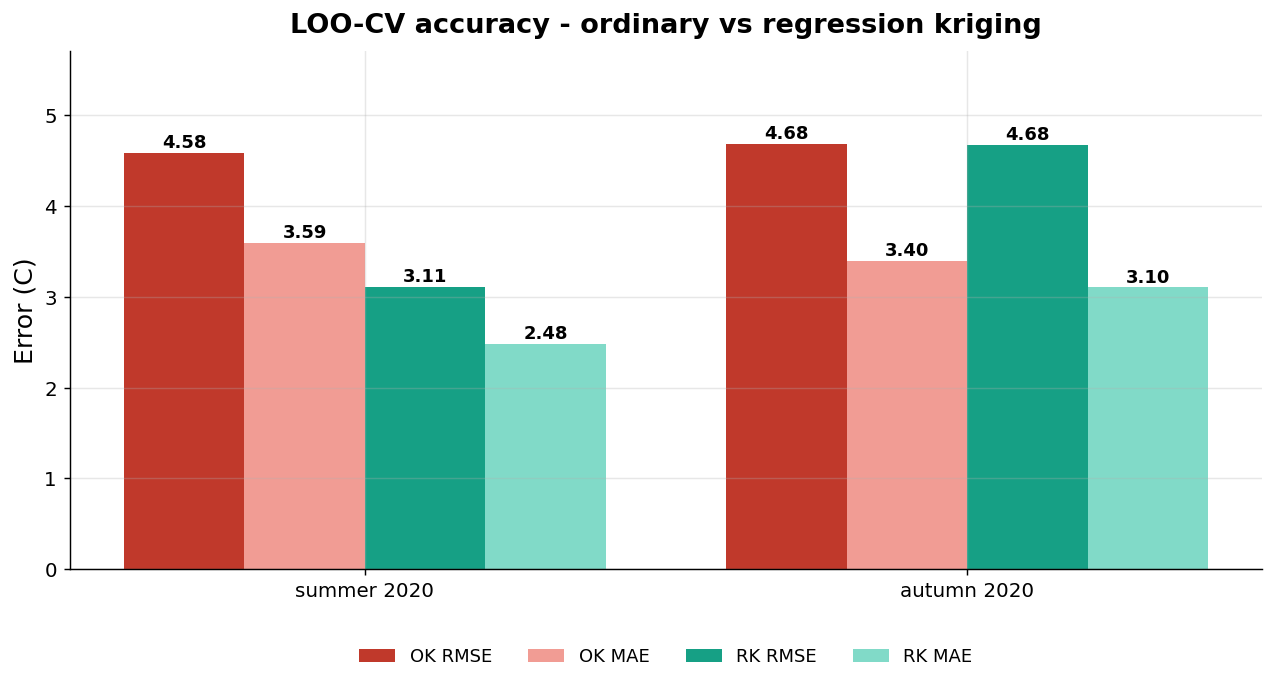

In [12]:

labels = ["summer 2020", "autumn 2020"]
ok_rmse = [results[(results.period == p) &
                   (results.analysis == "Real NOAA — ordinary ST kriging (pooled)")]["rmse"].iloc[0]
           for p in labels]
rk_rmse = [results[(results.period == p) &
                   (results.analysis == "Real NOAA — regression ST kriging")]["rmse"].iloc[0]
           for p in labels]
ok_mae = [results[(results.period == p) &
                  (results.analysis == "Real NOAA — ordinary ST kriging (pooled)")]["mae"].iloc[0]
          for p in labels]
rk_mae = [results[(results.period == p) &
                  (results.analysis == "Real NOAA — regression ST kriging")]["mae"].iloc[0]
          for p in labels]

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(labels))
width = 0.2
b1 = ax.bar(x - 1.5 * width, ok_rmse, width, color="#c0392b", label="OK RMSE")
b2 = ax.bar(x - 0.5 * width, ok_mae,  width, color="#e74c3c", alpha=0.55, label="OK MAE")
b3 = ax.bar(x + 0.5 * width, rk_rmse, width, color="#16a085", label="RK RMSE")
b4 = ax.bar(x + 1.5 * width, rk_mae,  width, color="#1abc9c", alpha=0.55, label="RK MAE")
for bars in (b1, b2, b3, b4):
    for rect in bars:
        ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.06,
                f"{rect.get_height():.2f}", ha="center", fontsize=10, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Error (C)")
ax.set_ylim(0, max(ok_rmse + rk_rmse) * 1.22)
ax.set_title("LOO-CV accuracy - ordinary vs regression kriging", pad=10)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False)
fig.tight_layout()
savefig(fig, "slide5_rmse_mae_bars")
plt.show()


In [13]:

n_stations = len(stations_s); T = Y_s.shape[1]
Y_hat_rk = np.full_like(Y_s, np.nan)
for i in range(n_stations):
    keep_i = np.arange(n_stations) != i
    elev_i = elev[keep_i]
    m_per_hour_i = np.nanmean(Y_s[keep_i], axis=0)
    Y_anom_i = Y_s[keep_i] - m_per_hour_i[None, :]
    st_mean_i = np.nanmean(Y_anom_i, axis=1)
    Xd_i = np.column_stack([np.ones_like(elev_i), elev_i])
    beta_i, *_ = np.linalg.lstsq(Xd_i, st_mean_i, rcond=None)
    Y_resid_i = Y_anom_i - (Xd_i @ beta_i)[:, None]
    dist_i = dist_s[np.ix_(keep_i, keep_i)]
    H_i, U_i, G_i, Nc_i = K.empirical_st_variogram(
        Y_resid_i, dist_i, t_axis=t_hours, max_pairs=30000,
        rng=np.random.default_rng(SEED + i),
    )
    p_i, _ = K.fit_sum_metric(H_i, U_i, G_i, Nc_i)
    X_km_i = X_km[keep_i]
    obs_rows = []; obs_t = []; obs_y = []
    for j in range(T):
        v = Y_resid_i[:, j]; mm = ~np.isnan(v)
        if mm.any():
            obs_rows.append(X_km_i[mm]); obs_t.append(np.full(mm.sum(), t_hours[j]))
            obs_y.append(v[mm])
    if not obs_rows: continue
    X_obs_i = np.vstack(obs_rows); t_obs_i = np.concatenate(obs_t); y_obs_i = np.concatenate(obs_y)
    X_pred_i = np.tile(X_km[i:i+1], (T, 1))
    preds_ri, _ = K.ordinary_st_kriging_local(
        X_obs_i, t_obs_i, y_obs_i, X_pred_i, t_hours, p_i,
        n_neighbors=min(80, len(y_obs_i)),
    )
    Y_hat_rk[i] = m_per_hour_i + beta_i[0] + beta_i[1] * elev[i] + preds_ri
print("RK LOO done")


RK LOO done


  saved slide5_scatter_and_errors.png


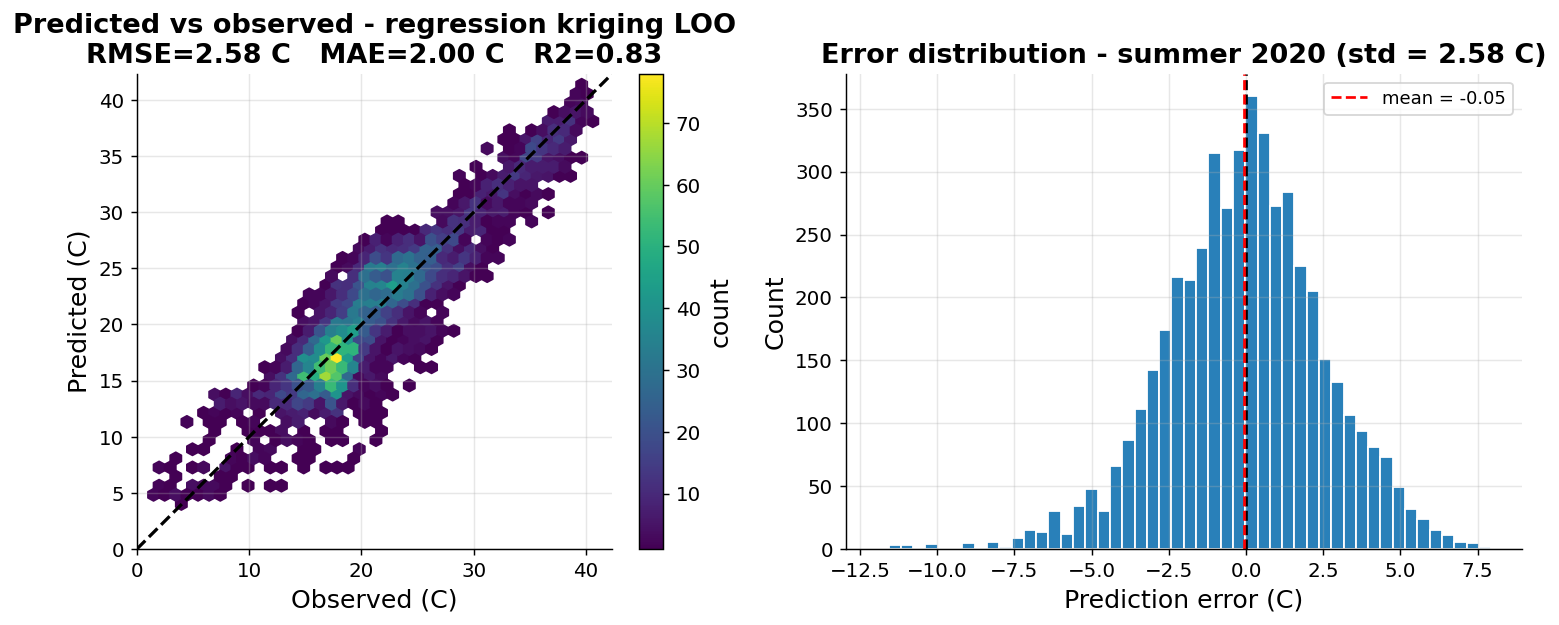

In [14]:

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
ax = axes[0]
y_t = Y_s.ravel(); y_p = Y_hat_rk.ravel()
mm = np.isfinite(y_t) & np.isfinite(y_p)
hb = ax.hexbin(y_t[mm], y_p[mm], gridsize=40, cmap="viridis", mincnt=1)
lo = min(y_t[mm].min(), y_p[mm].min()) - 1
hi = max(y_t[mm].max(), y_p[mm].max()) + 1
ax.plot([lo, hi], [lo, hi], "k--", lw=1.8)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
ax.set_xlabel("Observed (C)"); ax.set_ylabel("Predicted (C)")
rmse_p = K.rmse(y_t, y_p); mae_p = K.mae(y_t, y_p); r2_p = K.r2_score(y_t, y_p)
ax.set_title(f"Predicted vs observed - regression kriging LOO\n"
             f"RMSE={rmse_p:.2f} C   MAE={mae_p:.2f} C   R2={r2_p:.2f}")
fig.colorbar(hb, ax=ax, fraction=0.045, pad=0.04).set_label("count")

ax = axes[1]
err = (y_p - y_t)[mm]
ax.hist(err, bins=50, color="#2980b9", edgecolor="white")
ax.axvline(0, ls="--", color="black", lw=1.5)
ax.axvline(err.mean(), ls="--", color="red", lw=1.5, label=f"mean = {err.mean():+.2f}")
ax.set_xlabel("Prediction error (C)"); ax.set_ylabel("Count")
ax.set_title(f"Error distribution - summer 2020 (std = {err.std():.2f} C)")
ax.legend()
fig.tight_layout()
savefig(fig, "slide5_scatter_and_errors")
plt.show()


  saved slide5_final_summary.png


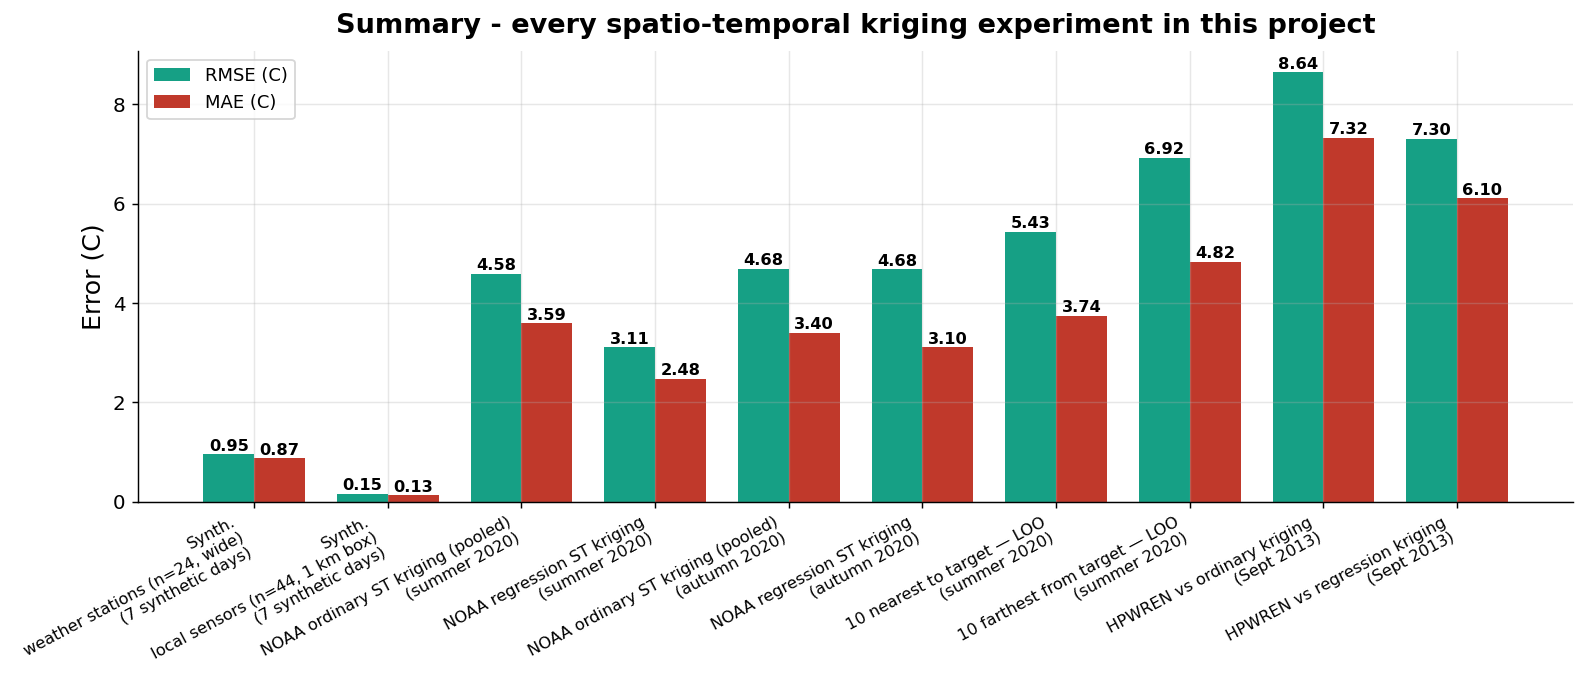

In [15]:

fig, ax = plt.subplots(figsize=(12.5, 5.5))
xs = np.arange(len(results))
width = 0.38
rmse_vals = results["rmse"].values; mae_vals = results["mae"].values
short = [a.replace("Real NOAA — ", "NOAA ").replace("Synthetic — ", "Synth.\n")
         + f"\n({p})" for a, p in zip(results["analysis"], results["period"])]
ax.bar(xs - width / 2, rmse_vals, width, color="#16a085", label="RMSE (C)")
ax.bar(xs + width / 2, mae_vals, width, color="#c0392b", label="MAE (C)")
for x, v in zip(xs - width / 2, rmse_vals):
    ax.text(x, v + 0.08, f"{v:.2f}", ha="center", fontsize=9, fontweight="bold")
for x, v in zip(xs + width / 2, mae_vals):
    ax.text(x, v + 0.08, f"{v:.2f}", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(xs); ax.set_xticklabels(short, rotation=28, ha="right", fontsize=9)
ax.set_ylabel("Error (C)")
ax.set_title("Summary - every spatio-temporal kriging experiment in this project", pad=10)
ax.legend(loc="upper left")
fig.tight_layout()
savefig(fig, "slide5_final_summary")
plt.show()
